# 03. Модель высот зданий

**Pipeline:** Загрузка unified -> Feature engineering (65 признаков) -> Train XGBoost на matched -> Predict для unknown -> Сохранение final dataset

**Входные данные:** `data/unified.parquet` (из 02_matching)

**Подход:** Nature 2024 (65 morphological features) + Spatial Autocorrelation (lag features)

In [14]:
# ============================================================
# КОНФИГ — менять параметры для тестирования гипотез
# ============================================================

from utils import CONFIG

CONTEXT_RADII = (50, 100, 250, 500, 1000)
SPATIAL_LAG_K = (5, 10, 20, 50)

TEST_SIZE = 0.2
RANDOM_STATE = 42
USE_LOG_TARGET = True  # log1p(height) — снижает завышение для мелких зданий

# XGBoost deep — лучший по OSM ML cross-check
XGBOOST_PARAMS = {
    'n_estimators': 800, 'max_depth': 10, 'learning_rate': 0.03,
    'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 3,
    'reg_lambda': 3, 'random_state': RANDOM_STATE, 'n_jobs': -1,
}

MIN_HEIGHT_TRAIN = 1.0
MAX_HEIGHT_TRAIN = 200.0

print(f"XGBoost: {XGBOOST_PARAMS}")
print(f"Log target: {USE_LOG_TARGET}")
print(f"purpose убран (46% importance, 100% NaN для only_A)")

XGBoost: {'n_estimators': 800, 'max_depth': 10, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 3, 'reg_lambda': 3, 'random_state': 42, 'n_jobs': -1}
Log target: True
purpose убран (46% importance, 100% NaN для only_A)


In [15]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from utils import (
    load_gdf, save_gdf, CONFIG,
    extract_geometric_features,
    extract_contextual_features,
    extract_spatial_lag_features,
    compute_height_metrics,
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline

## 1. Загрузка unified dataset

In [16]:
gdf = load_gdf(CONFIG['unified'])
print(f"Unified dataset: {len(gdf):,} зданий")
print(f"  С высотой: {gdf['height_known'].sum():,}")
print(f"  Без высоты: {(~gdf['height_known']).sum():,}")

# Проецируем для вычисления метрических фичей
gdf_proj = gdf.to_crs(CONFIG['crs_projected'])

Unified dataset: 196,807 зданий
  С высотой: 160,750
  Без высоты: 36,057


## 2. Feature Engineering

### 2.1 Геометрические признаки (8 фичей)
Из формы полигона: area, perimeter, vertices, compactness, complexity, convexity, rectangularity

In [17]:
%%time
print("Извлечение геометрических признаков...")
df_geom = extract_geometric_features(gdf_proj)
print(f"  Геометрические: {df_geom.shape[1]} признаков")
print(df_geom.describe().round(2))

Извлечение геометрических признаков...
  Геометрические: 8 признаков
            area  perimeter  n_vertices  compactness  complexity_ratio  \
count  196807.00  196807.00   196807.00    196807.00         196807.00   
mean      427.67      84.35        7.52         0.63              4.78   
std      1228.28     114.95        7.71         0.19              1.45   
min         0.00       0.16        4.00         0.01              3.55   
25%        35.80      24.72        5.00         0.53              4.03   
50%        89.64      40.50        5.00         0.71              4.21   
75%       431.36     100.47        7.00         0.77              4.87   
max     72631.75    7912.56      503.00         1.00             32.90   

       convex_area  convexity  rectangularity  
count    196807.00  196807.00       196807.00  
mean        548.63       0.95            0.91  
std        1768.76       0.11            0.15  
min           0.00       0.03            0.02  
25%          36.01      

### 2.2 Контекстуальные признаки (20 фичей)
Характеристики окружения на 5 масштабах: 50/100/250/500/1000 м

In [18]:
%%time
print(f"Извлечение контекстуальных признаков (радиусы: {CONTEXT_RADII})...")
df_ctx = extract_contextual_features(gdf_proj, radii=CONTEXT_RADII)
print(f"  Контекстуальные: {df_ctx.shape[1]} признаков")
print(df_ctx.describe().round(2))

Извлечение контекстуальных признаков (радиусы: (50, 100, 250, 500, 1000))...
  Контекстуальные: 20 признаков
       n_buildings_50m  mean_area_50m  max_area_50m  density_50m  \
count        196807.00      196807.00     196807.00    196807.00   
mean              6.21         333.43        831.60         0.19   
std               4.83         559.25       1217.99         0.21   
min               0.00           0.00          0.00         0.00   
25%               3.00          60.21        120.51         0.05   
50%               5.00         210.67        507.32         0.13   
75%               8.00         418.59       1114.77         0.27   
max              49.00       43471.16      60887.92         8.15   

       n_buildings_100m  mean_area_100m  max_area_100m  density_100m  \
count         196807.00       196807.00      196807.00     196807.00   
mean              22.12          402.11        1908.91          0.20   
std               15.68          511.30        2289.11        

### 2.3 Spatial lag признаки (4 фичи)
Взвешенные средние высоты k ближайших соседей — кодируют пространственную автокорреляцию

In [19]:
%%time
print(f"Извлечение spatial lag признаков (k={SPATIAL_LAG_K})...")

# Для spatial lag нужна колонка height в gdf_proj
gdf_proj['height'] = gdf['height'].values
df_lag = extract_spatial_lag_features(gdf_proj, 'height', k_values=SPATIAL_LAG_K)
print(f"  Spatial lag: {df_lag.shape[1]} признаков")
print(f"  NaN (здания без соседей с высотой): {df_lag.isna().any(axis=1).sum()}")

Извлечение spatial lag признаков (k=(5, 10, 20, 50))...
  Spatial lag: 4 признаков
  NaN (здания без соседей с высотой): 4115
CPU times: user 5.77 s, sys: 75.9 ms, total: 5.84 s
Wall time: 5.89 s


### 2.4 Категориальные + пространственные + size-aware признаки
- tag_main (без purpose — target leak для only_A)
- Координаты, dist_to_center, neighbourhood height stats
- Size-aware: area_pctile, area_ratio, is_smallest, tag-specific lag, tag split by area

In [20]:
from scipy.spatial import cKDTree as cKDTree2

df_cat = pd.DataFrame(index=gdf.index)

# tag_main — top N + other
top_tags = gdf['tag_main'].value_counts().head(10).index.tolist()
tag_clean = gdf['tag_main'].where(gdf['tag_main'].isin(top_tags), 'other')
df_cat = pd.concat([df_cat, pd.get_dummies(tag_clean, prefix='tag').astype(float)], axis=1)

# purpose УБРАН — 46% importance но 100% NaN для only_A
# Модель переобучалась на purpose и плохо предсказывала без него

# НЕ добавляем stairs, gkh_floor_max/min — target leak

# Пространственные фичи
centroids_proj = np.column_stack([gdf_proj.geometry.centroid.x, gdf_proj.geometry.centroid.y])
areas_proj = gdf_proj.geometry.area.values
CENTER_SPB = np.array([332700, 6647000])
df_cat['dist_to_center'] = np.sqrt((centroids_proj[:, 0] - CENTER_SPB[0])**2 + (centroids_proj[:, 1] - CENTER_SPB[1])**2)
df_cat['centroid_x'] = centroids_proj[:, 0]
df_cat['centroid_y'] = centroids_proj[:, 1]

# Neighbourhood height stats
heights_arr = gdf['height'].values
tree_h = cKDTree2(centroids_proj)
for k in [3, 10, 30]:
    dists_h, idx_h = tree_h.query(centroids_proj, k=k+1)
    nbr_h = heights_arr[idx_h[:, 1:]]
    with np.errstate(all='ignore'):
        df_cat[f'h_std_k{k}'] = np.nanstd(nbr_h, axis=1)
        df_cat[f'h_max_k{k}'] = np.nanmax(nbr_h, axis=1)
        df_cat[f'h_min_k{k}'] = np.nanmin(nbr_h, axis=1)

# === Size-aware фичи (улучшают предсказание для мелких зданий) ===

# Area percentile среди 20 ближайших соседей
d20, i20 = tree_h.query(centroids_proj, k=21)
nbr_areas = areas_proj[i20[:, 1:]]
df_cat['area_pctile_100m'] = np.array([
    np.searchsorted(np.sort(nbr_areas[i]), areas_proj[i]) / 20.0 
    for i in range(len(areas_proj))
])

# Ratio площади к средней соседей
df_cat['area_ratio_to_nbrs'] = areas_proj / (nbr_areas.mean(axis=1) + 1e-10)

# Самое маленькое в окружении?
df_cat['is_smallest_50m'] = (areas_proj < nbr_areas.min(axis=1)).astype(float)

# Tag-specific spatial lag (высота соседей того же типа)
for t in ['постройка', 'жилое здание', 'промышленность']:
    mask_t = (gdf['tag_main'] == t).values
    if mask_t.sum() > 100:
        c_t = centroids_proj[mask_t]; h_t = heights_arr[mask_t]
        tree_t = cKDTree2(c_t)
        d_t, i_t = tree_t.query(centroids_proj, k=6)
        with np.errstate(all='ignore'):
            df_cat[f'h_lag_{t}_k5'] = np.nanmean(h_t[i_t[:, 1:]], axis=1)

# Tag split by area (разные поведения для маленьких/больших зданий одного тега)
for t in top_tags:
    is_t = (gdf['tag_main'] == t).values
    df_cat[f'tag_{t}_small'] = (is_t & (areas_proj < 50)).astype(float)
    df_cat[f'tag_{t}_large'] = (is_t & (areas_proj >= 200)).astype(float)

df_cat = df_cat.replace([np.inf, -np.inf], np.nan)
print(f"  Категориальные + пространственные + size-aware: {df_cat.shape[1]} признаков")
print(f"  (purpose убран, добавлены area_pctile, area_ratio, is_smallest, tag-specific lag, tag split)")

  Категориальные + пространственные + size-aware: 49 признаков
  (purpose убран, добавлены area_pctile, area_ratio, is_smallest, tag-specific lag, tag split)


### 2.5 Сборка матрицы признаков

In [21]:
# Собираем все фичи
X_all = pd.concat([df_geom, df_ctx, df_lag, df_cat], axis=1)
X_all['match_type_code'] = gdf['match_type'].map({'matched': 2, 'only_b': 1, 'only_a': 0})

# Целевая переменная
y_all = gdf['height'].values

# Маска для обучения
train_mask = (
    gdf['height_known'] &
    (gdf['height'] >= MIN_HEIGHT_TRAIN) &
    (gdf['height'] <= MAX_HEIGHT_TRAIN)
)
predict_mask = ~gdf['height_known']

# === Target encoding по tag_main (считаем на train only) ===
tag_col = gdf['tag_main'].copy()
train_idx = gdf.index[train_mask]
tag_stats = pd.DataFrame({
    'tag': tag_col.iloc[train_idx],
    'height': y_all[train_idx]
}).groupby('tag')['height'].agg(['mean', 'median', 'std'])
tag_stats.columns = ['tag_h_mean', 'tag_h_median', 'tag_h_std']

X_all['tag_h_mean'] = tag_col.map(tag_stats['tag_h_mean']).values
X_all['tag_h_median'] = tag_col.map(tag_stats['tag_h_median']).values
X_all['tag_h_std'] = tag_col.map(tag_stats['tag_h_std']).values

print(f"Итого матрица признаков: {X_all.shape}")
print(f"Признаков: {X_all.shape[1]} (вкл. 3 target encoding)")
print(f"\nДля обучения: {train_mask.sum():,}")
print(f"Для предсказания: {predict_mask.sum():,}")

# Сохраняем промежуточно
features_gdf = gdf.copy()
for col in X_all.columns:
    features_gdf[col] = X_all[col].values
save_gdf(features_gdf.to_crs(CONFIG['crs_geo']), './data/features.parquet')

Итого матрица признаков: (196807, 85)
Признаков: 85 (вкл. 3 target encoding)

Для обучения: 160,748
Для предсказания: 36,057
  Сохранено: ./data/features.parquet (196807 записей)


## 3. Обучение XGBoost

Train на matched зданиях с известной высотой, eval на hold-out 20%.

In [22]:
%%time
X_train_all = X_all[train_mask].copy()
y_train_all = y_all[train_mask]
X_train_all = X_train_all.fillna(X_train_all.median())

X_train, X_test, y_train, y_test = train_test_split(
    X_train_all, y_train_all, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train):,}, Test: {len(X_test):,}, Features: {X_train.shape[1]}")

# log target для лучшего предсказания мелких зданий
y_train_t = np.log1p(y_train) if USE_LOG_TARGET else y_train
y_test_t = np.log1p(y_test) if USE_LOG_TARGET else y_test

print(f"\nОбучение XGBoost (log target={USE_LOG_TARGET})...")
model = XGBRegressor(**XGBOOST_PARAMS)
model.fit(X_train, y_train_t, eval_set=[(X_test, y_test_t)], verbose=100)

# Метрики
y_pred_test = np.expm1(model.predict(X_test)) if USE_LOG_TARGET else model.predict(X_test)
metrics = compute_height_metrics(y_test, y_pred_test)

print(f"\n=== Метрики на test set ===")
for k, v in metrics.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

Train: 128,598, Test: 32,150, Features: 85

Обучение XGBoost (log target=True)...
[0]	validation_0-rmse:0.75341
[100]	validation_0-rmse:0.29873
[200]	validation_0-rmse:0.29135
[300]	validation_0-rmse:0.28976
[400]	validation_0-rmse:0.28849
[500]	validation_0-rmse:0.28764
[600]	validation_0-rmse:0.28715
[700]	validation_0-rmse:0.28680
[799]	validation_0-rmse:0.28640

=== Метрики на test set ===
  MAE: 2.247
  RMSE: 5.089
  R2: 0.885
  pct_under_3m: 78.124
  pct_under_5m: 88.134
  p95_error: 8.617
  n_samples: 32150
CPU times: user 48.7 s, sys: 3.99 s, total: 52.6 s
Wall time: 11.2 s


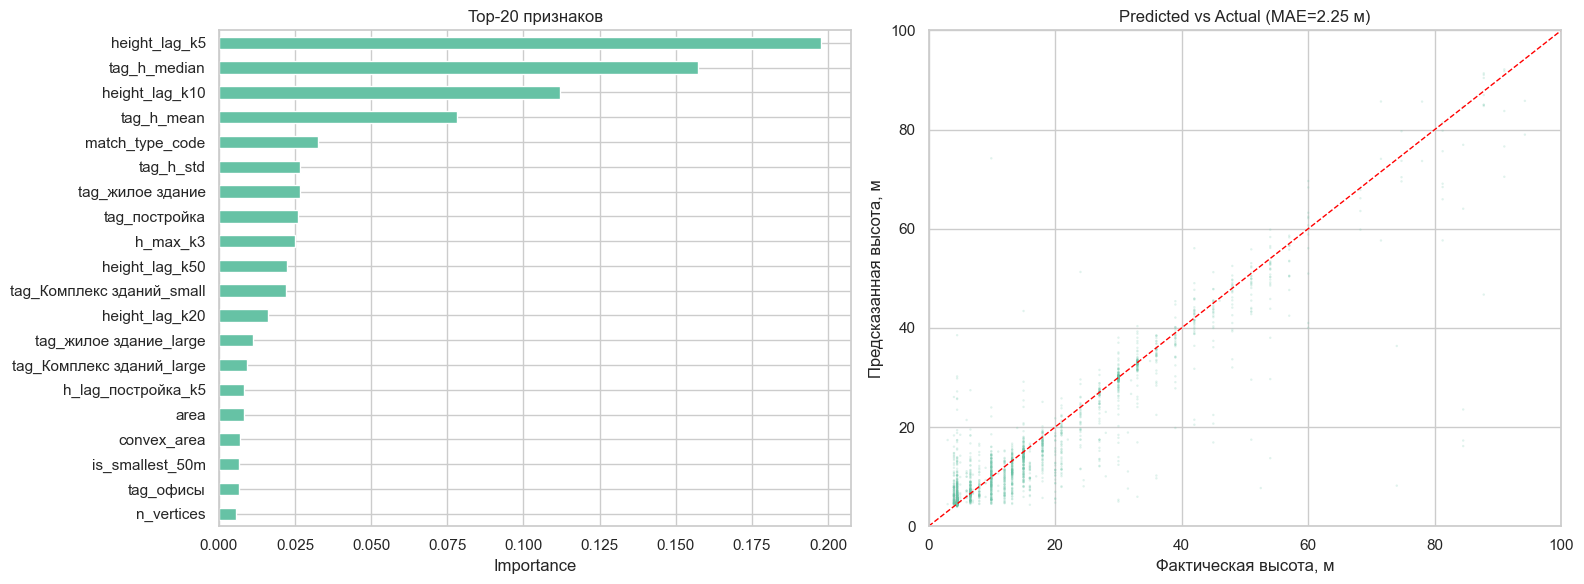

In [23]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=X_train.columns)
top20 = importance.nlargest(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top-20 feature importance
top20.plot.barh(ax=axes[0], color='#66c2a5')
axes[0].set_xlabel('Importance')
axes[0].set_title('Top-20 признаков')
axes[0].invert_yaxis()

# Predicted vs Actual
sample_idx = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
axes[1].scatter(y_test[sample_idx], y_pred_test[sample_idx], s=3, alpha=0.2, edgecolors='none')
axes[1].plot([0, 200], [0, 200], 'r--', lw=1)
axes[1].set_xlabel('Фактическая высота, м')
axes[1].set_ylabel('Предсказанная высота, м')
axes[1].set_title(f'Predicted vs Actual (MAE={metrics["MAE"]:.2f} м)')
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

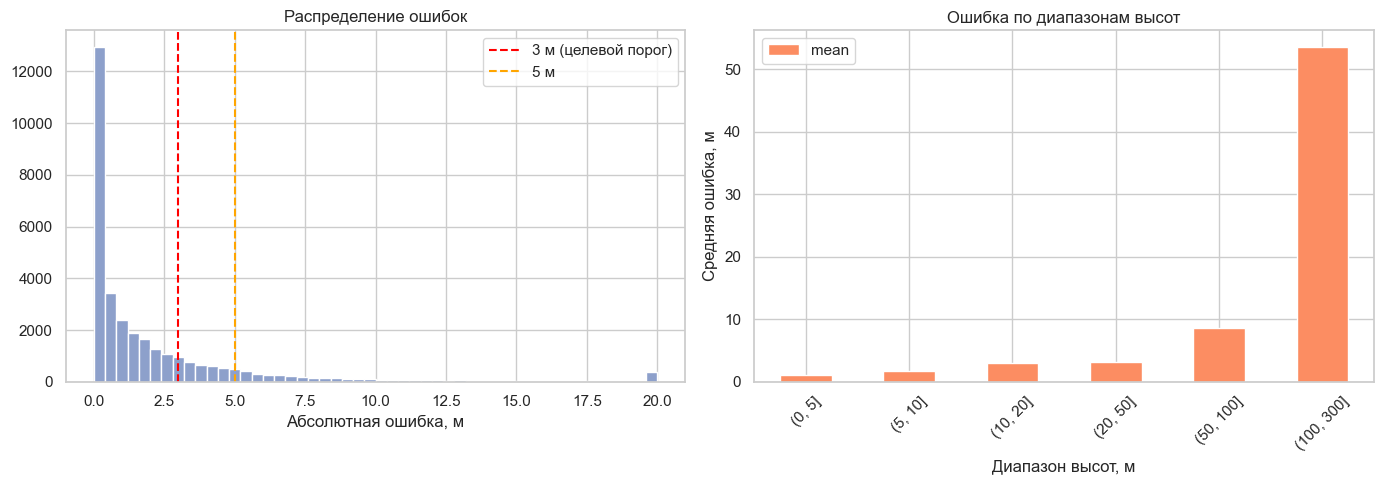

In [24]:
# Распределение ошибок
errors = np.abs(y_test - y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.clip(errors, 0, 20), bins=50, edgecolor='white', color='#8da0cb')
axes[0].axvline(3, color='red', ls='--', label='3 м (целевой порог)')
axes[0].axvline(5, color='orange', ls='--', label='5 м')
axes[0].set_xlabel('Абсолютная ошибка, м')
axes[0].set_title('Распределение ошибок')
axes[0].legend()

# Ошибка по диапазонам высот
height_bins = pd.cut(y_test, bins=[0, 5, 10, 20, 50, 100, 300])
error_by_bin = pd.DataFrame({'error': errors, 'height_bin': height_bins})
error_by_bin.groupby('height_bin')['error'].agg(['mean', 'median', 'count']).plot.bar(
    y='mean', ax=axes[1], color='#fc8d62', edgecolor='white'
)
axes[1].set_xlabel('Диапазон высот, м')
axes[1].set_ylabel('Средняя ошибка, м')
axes[1].set_title('Ошибка по диапазонам высот')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Предсказание высот для зданий без данных

In [25]:
# Предсказание для зданий без высоты
X_predict = X_all[predict_mask].copy()
X_predict = X_predict.fillna(X_all[train_mask].median())

y_predicted = model.predict(X_predict)
if USE_LOG_TARGET:
    y_predicted = np.expm1(y_predicted)

y_predicted = np.clip(y_predicted, 1.0, 300.0)

print(f"Предсказано высот: {len(y_predicted):,}")
print(f"  Диапазон: [{y_predicted.min():.1f}, {y_predicted.max():.1f}] м")
print(f"  Медиана: {np.median(y_predicted):.1f} м")
print(f"  Среднее: {y_predicted.mean():.1f} м")

gdf_final = gdf.copy()
gdf_final.loc[predict_mask, 'height'] = y_predicted
gdf_final['height_source'] = 'source_b'
gdf_final.loc[predict_mask, 'height_source'] = 'ml_predicted'
gdf_final['height_known'] = True

print(f"\nИтого: {len(gdf_final):,} зданий, все с высотой")
print(f"  Из Источника Б: {(gdf_final['height_source'] == 'source_b').sum():,}")
print(f"  ML-предсказание: {(gdf_final['height_source'] == 'ml_predicted').sum():,}")

Предсказано высот: 36,057
  Диапазон: [2.8, 86.2] м
  Медиана: 5.1 м
  Среднее: 8.4 м

Итого: 196,807 зданий, все с высотой
  Из Источника Б: 160,750
  ML-предсказание: 36,057


In [26]:
# Сохраняем финальный датасет в 3 форматах
save_gdf(gdf_final, './data/final.parquet')

# CSV
df_csv = gdf_final.copy()
df_csv['wkt'] = gdf_final.geometry.to_wkt()
df_csv = df_csv.drop(columns=['geometry'])
df_csv.to_csv('./data/final.csv', index=False)
print(f"  CSV: data/final.csv ({len(df_csv):,} записей)")

# Shapefile
import os
os.makedirs('./data/shp', exist_ok=True)
gdf_shp = gdf_final[['geometry', 'height', 'match_type', 'geom_source', 'area_m2']].copy()
gdf_shp.columns = ['geometry', 'height', 'match_typ', 'geom_src', 'area_m2']
gdf_shp = gdf_shp[gdf_shp.geometry.notna()]
gdf_shp.to_file('./data/shp/buildings_spb.shp')
print(f"  Shapefile: data/shp/buildings_spb.shp")

# Модель
import pickle
with open('./data/xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("  Модель: data/xgb_model.pkl")

  Сохранено: ./data/final.parquet (196807 записей)
  CSV: data/final.csv (196,807 записей)
  Shapefile: data/shp/buildings_spb.shp
  Модель: data/xgb_model.pkl
